In [ ]:
!pip install timm

import torch
import torch.nn as nn
import torch.optim as optim
import timm
import os
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns

In [ ]:
DATA_DIR = "/content/drive/MyDrive/ML/dataset/stage1_leaf_classifier"

train_dir = os.path.join(DATA_DIR, "train")
val_dir   = os.path.join(DATA_DIR, "val")
test_dir  = os.path.join(DATA_DIR, "test")

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.RandomAffine(10),
    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [ ]:
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset   = datasets.ImageFolder(val_dir, transform=val_transform)
test_dataset  = datasets.ImageFolder(test_dir, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

classes = train_dataset.classes
print("Classes:", classes)

In [ ]:
labels = train_dataset.targets

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

weights = torch.tensor(class_weights, dtype=torch.float).cuda()

print("Class Weights:", weights)

In [ ]:
class EnsembleModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.resnet = timm.create_model("resnet50", pretrained=True, num_classes=2)
        self.effnet = timm.create_model("efficientnet_b0", pretrained=True, num_classes=2)

    def forward(self, x):
        out1 = self.resnet(x)
        out2 = self.effnet(x)
        return (out1 + out2) / 2

model = EnsembleModel().cuda()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

In [ ]:
criterion = nn.CrossEntropyLoss(weight=weights)

optimizer = optim.Adam(model.parameters(), lr=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=2, factor=0.5
)

In [ ]:
best_val_loss = float("inf")
patience = 5
counter = 0

train_losses, val_losses = [], []
train_accs, val_accs = [],[]

In [ ]:
EPOCHS = 20

for epoch in range(EPOCHS):

    # ===== TRAIN =====
    model.train()
    train_loss, correct = 0, 0

    for images, labels in train_loader:
        images, labels = images.cuda(), labels.cuda()

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()

    train_acc = correct / len(train_dataset)
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # ===== VALIDATION =====
    model.eval()
    val_loss, correct = 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.cuda(), labels.cuda()

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()

    val_acc = correct / len(val_dataset)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    scheduler.step(val_loss)

    print(f"\nEpoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f} | Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Acc: {val_acc:.4f}")

    # ===== EARLY STOPPING =====
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(),
                   "/content/drive/MyDrive/ML/models/best_stage1.pt")
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered")
            break


Epoch 1
Train Loss: 16.6935 | Acc: 0.9329
Val Loss: 0.9156 | Acc: 0.9783

Epoch 2
Train Loss: 6.3008 | Acc: 0.9744
Val Loss: 0.8862 | Acc: 0.9876

Epoch 3
Train Loss: 4.7211 | Acc: 0.9817
Val Loss: 0.3752 | Acc: 0.9923

Epoch 4
Train Loss: 2.5547 | Acc: 0.9900
Val Loss: 0.3564 | Acc: 0.9938

Epoch 5
Train Loss: 2.1886 | Acc: 0.9907
Val Loss: 0.4534 | Acc: 0.9954

Epoch 6
Train Loss: 5.0433 | Acc: 0.9934
Val Loss: 0.6685 | Acc: 0.9876

Epoch 7
Train Loss: 2.8500 | Acc: 0.9894
Val Loss: 0.2385 | Acc: 0.9954

Epoch 8
Train Loss: 1.6830 | Acc: 0.9944
Val Loss: 0.2799 | Acc: 0.9938

Epoch 9
Train Loss: 0.6020 | Acc: 0.9980
Val Loss: 0.1459 | Acc: 0.9985

Epoch 10
Train Loss: 0.8519 | Acc: 0.9960
Val Loss: 0.3613 | Acc: 0.9954

Epoch 11
Train Loss: 0.4543 | Acc: 0.9983
Val Loss: 0.1508 | Acc: 0.9985

Epoch 12
Train Loss: 1.5619 | Acc: 0.9970
Val Loss: 0.2586 | Acc: 0.9969

Epoch 13
Train Loss: 1.7562 | Acc: 0.9927
Val Loss: 0.1951 | Acc: 0.9954

Epoch 14
Train Loss: 1.2267 | Acc: 0.9963
Val

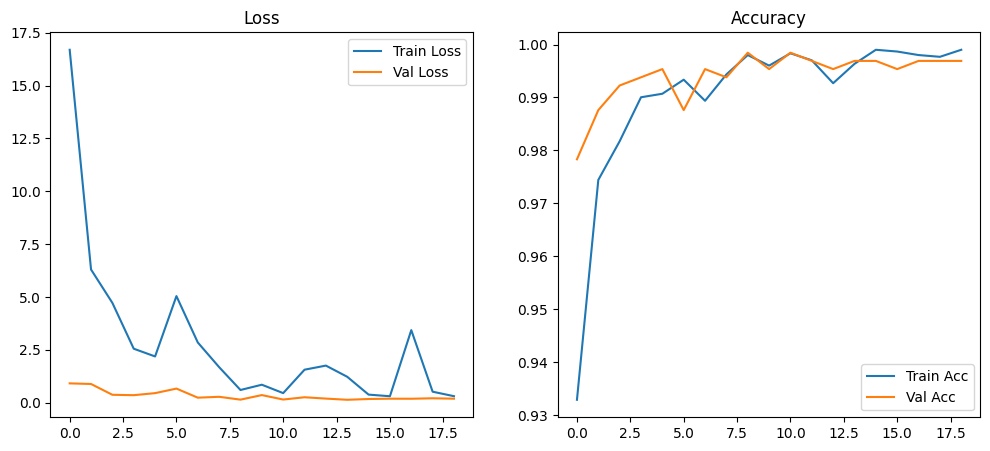

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.legend()
plt.title("Accuracy")

plt.show()

In [ ]:
model.load_state_dict(torch.load("/content/drive/MyDrive/ML/models/best_stage1.pt"))
model.eval()

y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.cuda()

        outputs = model(images)
        preds = outputs.argmax(1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

In [ ]:
print(classification_report(y_true, y_pred, target_names=classes))

              precision    recall  f1-score   support

  other_leaf       0.99      1.00      1.00       323
 potato_leaf       1.00      0.99      1.00       323

    accuracy                           1.00       646
   macro avg       1.00      1.00      1.00       646
weighted avg       1.00      1.00      1.00       646



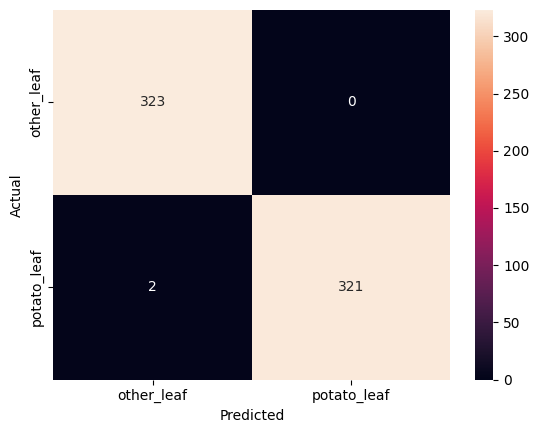

In [ ]:
cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=classes,
            yticklabels=classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Accuracy
accuracy = accuracy_score(y_true, y_pred)

# Precision (macro = for multi-class)
precision = precision_score(y_true, y_pred, average='macro')

# Recall
recall = recall_score(y_true, y_pred, average='macro')

# F1 Score
f1 = f1_score(y_true, y_pred, average='macro')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.9969040247678018
Precision: 0.9969230769230769
Recall: 0.9969040247678018
F1 Score: 0.9969039950924009


In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])